# Validation Narrabeen

## Paths & Co

In [1]:
new_kalman_run = False
animation = False

In [2]:
# paths jupyter utwente
path_tc = '/home/jovyan/data/98_paper2_kf_dtm/01_tides/output/'
path_validation = '/home/jovyan/data/98_paper2_kf_dtm/03_Narrabeen_validation_data/'

path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/32_33_Narrabeen_DEM/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/32_33_Narrabeen_DEM/output/'
path_altimetry_output = '/home/jovyan/data/98_paper2_kf_dtm/31_Narra_altimetry/output/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n-33.6_s-33.8_w151.2_e151.4.nc'
fn_ddtm = 'DeltaDTM_v1_0_S34E151.tif'

epsg = 4326 # WGS84
epsg_local = 32356

year_start = 1993
year_end = 2020 # included

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr

from scipy import stats

from shapely import LineString

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_visualisation

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [5]:
# Observational noise
sigma_l = 0.35

# Model noise
factor = 1
sigma_q = factor * sigma_l

# Standard deviation of the initial state
std_init = 3

print(f'Observational noise: {round(sigma_l,2)} m')
print(f'Model noise: {round(sigma_q,2)} m')
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.35 m
Model noise: 0.35 m
Standard deviation of the initial state: 3 m


In [6]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Observations

In [7]:
# Altimetry
fn = 'tp_plus_ales_epsg32356.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [8]:
# Tidal correction
fn = 'tides_narra.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [9]:
# Cassie shorelines
folders = ['1_1992-09-24_1998-04-18_spac100_ext1600_thresh0/',
          '2_1992-09-24_1998-04-18_spac100_ext400_thresh0/',
          '3_1998-05-20_2007-09-18_spac100_ext400_thresh0/',
          '4_2007-10-04_2016-10-28_spac100_ext400_thresh0/',
          '5_2016-11-13_2021-10-26_spac100_ext400_thresh0/',
          '6_2021-12-13_2025-04-20_spac100_ext300_thresh0/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

336 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 130 points (min: 34, max: 316).


In [10]:
# number of shorelines per year
pd.DataFrame([_.year for _ in c_dates]).value_counts(sort=False)

0   
1992     8
1993    33
1994    27
1995    18
1996    25
1997    26
1998    25
1999     8
2003     5
2004    17
2005    11
2006    11
2007    12
2008     6
2009    13
2010     4
2011     6
2013    13
2014    11
2015     9
2016     3
2017    13
2018    14
2019    14
2020     4
Name: count, dtype: int64

In [11]:
# Load outlier-corrected shorelines
c_shorelines_corr = pickle.load(open(path_output + 'c_shorelines_corr.pkl', 'rb'))
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

### Validation data

In [12]:
vali_gdf = gpd.read_file(path_output + 'narra_vali_gdf.geojson')

### Initial state

In [13]:
init = xr.open_dataset(path_output+'init_4326_resolution_50m.tif').squeeze()

### Polygons

In [14]:
med_sl = pickle.load(open(path_output + f'med_sl{epsg}.pkl', 'rb')) 
poly_target = pickle.load(open(path_output + f'poly_target{epsg}.pkl', 'rb')) 
poly_shorelines = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))
poly_target_red = pickle.load(open(path_output + f'poly_target_red_{epsg}.pkl', 'rb')) 
profile_polys = pickle.load(open(path_output + 'profile_polys.pkl', 'rb'))
profile_polys_red = pickle.load(open(path_output + 'profile_polys_red.pkl', 'rb'))

## Generate RTS-DTM

In [15]:
# %%prun -s cumulative
fn = 'x_state_s.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]
    
    x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(year_start, year_end, init, std_init, rs_shoreline, seg_length, alt, tidal_corr,
                                                                                          epsg, T_is_identity, max_distance, w_id, max_noupdate, std_pseudobs,
                                                                                          sigma_l, sigma_q, eps_factor)
            
    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)
        
    kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state, x_state_s, updated_points)

    # Save kf output
    pickle.dump(x_state, open(f'{path_output}x_state.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s, open(f'{path_output}x_state_s.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")
    

Loaded files from /home/jovyan/data/98_paper2_kf_dtm/32_33_Narrabeen_DEM/output/.


## Statistics of elevation differences (averaged over all profiles)

In [16]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(vali_gdf.geometry.x, vali_gdf.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', vali_gdf.geometry.x, vali_gdf.geometry.y)

In [17]:
# Reduce to area inside the shoreline polygon
init_inside_sl = init_interp[init_interp.intersects(poly_sl_corr)]
vali_inside_sl = vali_gdf[vali_gdf.intersects(poly_sl_corr)]
kf_inside_sl = kf_interp[kf_interp.intersects(poly_sl_corr)]
rts_inside_sl = rts_interp[rts_interp.intersects(poly_sl_corr)]

### Initial state - validation

In [18]:
vali_temp_mean = vali_gdf.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - vali_temp_mean
print(f'Difference initial state - vali has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - vali has 687 non-NaN values.


In [19]:
CD_statistics.print_stats(diff_init)

Mean error: 0.23 m
---De-bias with mean---
Mean error: 0.0 m
Mean absolute error: 2.47 m
Root mean square error: 2.95 m
Mean absolute deviation from mean: 2.47 m
Median absolute deviation from median: 2.33 m


In [20]:
year_list = [int(_) for _ in vali_inside_sl.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], vali_gdf, year_list, reduce_mean=True, static=True)

# Consider only points inside shoreline polygon
stats_gdf_init_in_sl, all_diffs_init_in_sl = CD_statistics.all_stats_per_year(init_inside_sl['init'], vali_inside_sl, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - validation

In [21]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, vali_gdf, year_list, reduce_mean=True, static=False)
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, vali_gdf, year_list, reduce_mean=True, static=False)

# Consider only points inside shoreline polygon
stats_gdf_rts_in_sl, all_diffs_rts_in_sl = CD_statistics.all_stats_per_year(rts_inside_sl, vali_inside_sl, year_list, reduce_mean=True, static=False)
stats_gdf_kf_in_sl, all_diffs_kf_in_sl = CD_statistics.all_stats_per_year(kf_inside_sl, vali_inside_sl, year_list, reduce_mean=True, static=False)

In [22]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

In [23]:
def plot_stats(ax, which_stat, title, legend=False, inside_sl=False):
    if inside_sl==False:
        ax.plot(stats_gdf_init.index.astype('int'), stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - validation')
        ax.plot(stats_gdf_kf.index.astype('int'), stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
        ax.plot(stats_gdf_rts.index.astype('int'), stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    elif inside_sl==True:
        ax.plot(stats_gdf_init_in_sl.index.astype('int'), stats_gdf_init_in_sl[which_stat], '.-', c=c_init, label='Initial state - validation')
        ax.plot(stats_gdf_kf_in_sl.index.astype('int'), stats_gdf_kf_in_sl[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
        ax.plot(stats_gdf_rts_in_sl.index.astype('int'), stats_gdf_rts_in_sl[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=25)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=23, y=1)
    # ax.ticklabel_format(useOffset=False, style='plain')

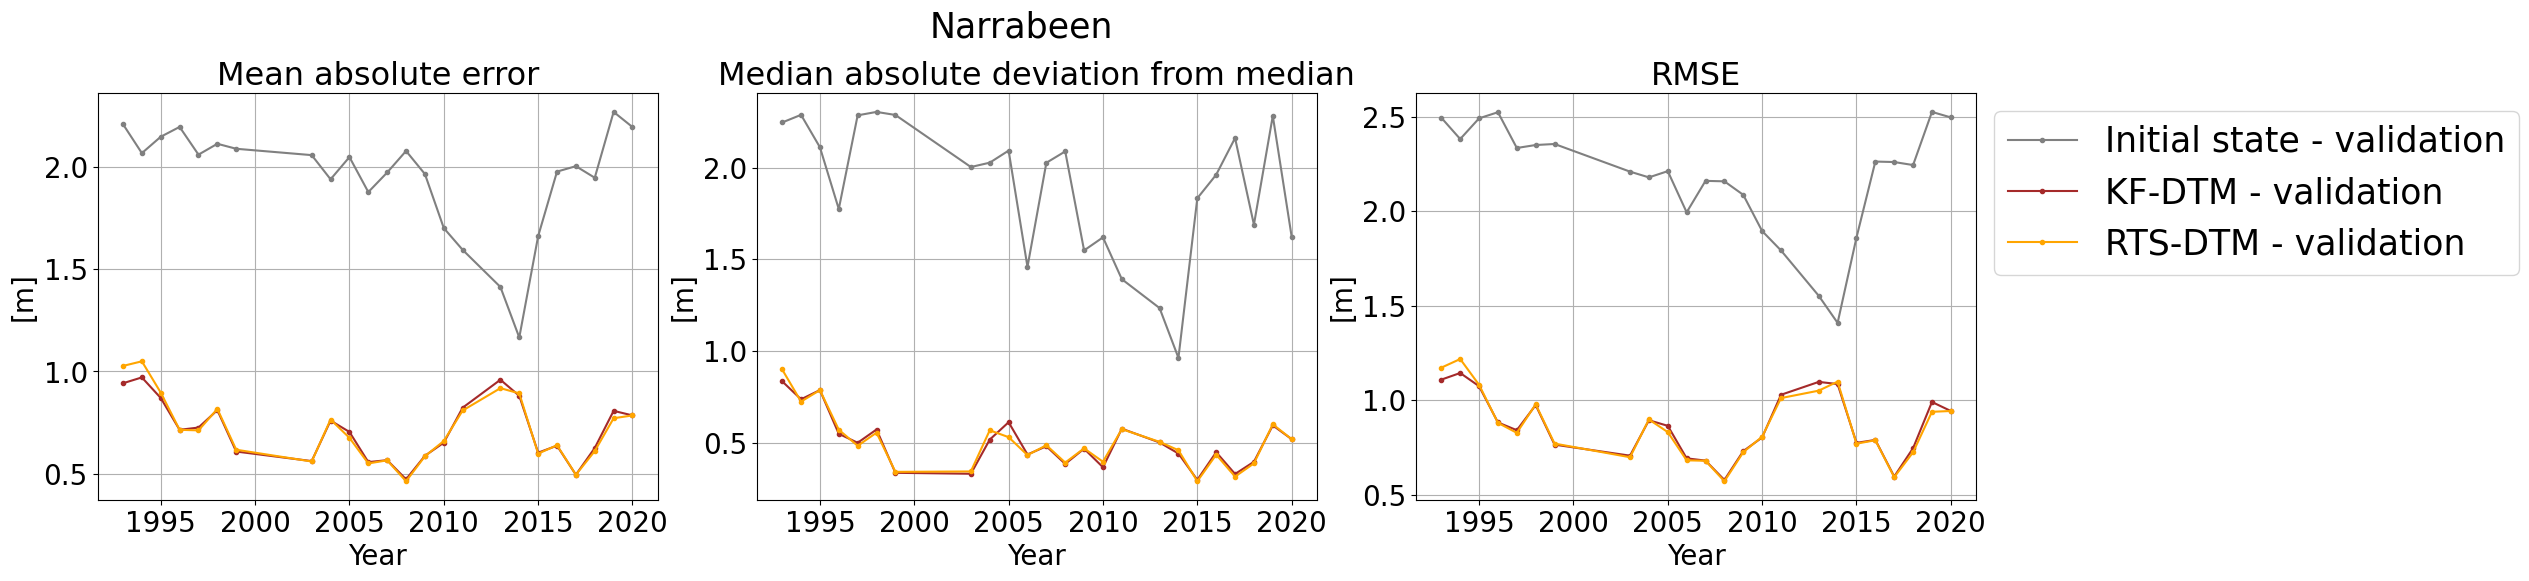

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle(f'Statistics of elevation differences averaged over the area covered by shoreline observations ({len(rts_inside_sl)} points)', y=1.1, fontsize=25)
fig.suptitle('Narrabeen', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error', inside_sl=True)
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median', inside_sl=True)
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True, inside_sl=True)

plt.savefig(f'{path_output}Narra_vali_stats_elev-diffs_inside_shoreline_poly.png', dpi=300, bbox_inches='tight')

#### Quantify difference init - KF/RTS
positive: init has (on average) larger error  
negative: KF/RTS has larger error  

In [26]:
print(f'Average difference init-KF (inside shoreline area):')
print(f'ME: {round((stats_gdf_init_in_sl.mae - stats_gdf_kf_in_sl.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init_in_sl.mad_med - stats_gdf_kf_in_sl.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init_in_sl.rmse - stats_gdf_kf_in_sl.rmse).mean(),2)} m')

print(f'\nAverage difference init-RTS (inside shoreline area):')
print(f'ME: {round((stats_gdf_init_in_sl.mae - stats_gdf_rts_in_sl.mae).mean(),2)} m')
print(f'MAD: {round((stats_gdf_init_in_sl.mad_med - stats_gdf_rts_in_sl.mad_med).mean(),2)} m')
print(f'RMSE: {round((stats_gdf_init_in_sl.rmse - stats_gdf_rts_in_sl.rmse).mean(),2)} m')

Average difference init-KF (inside shoreline area):
ME: 1.23 m
MAD: 1.39 m
RMSE: 1.31 m

Average difference init-RTS (inside shoreline area):
ME: 1.23 m
MAD: 1.38 m
RMSE: 1.31 m


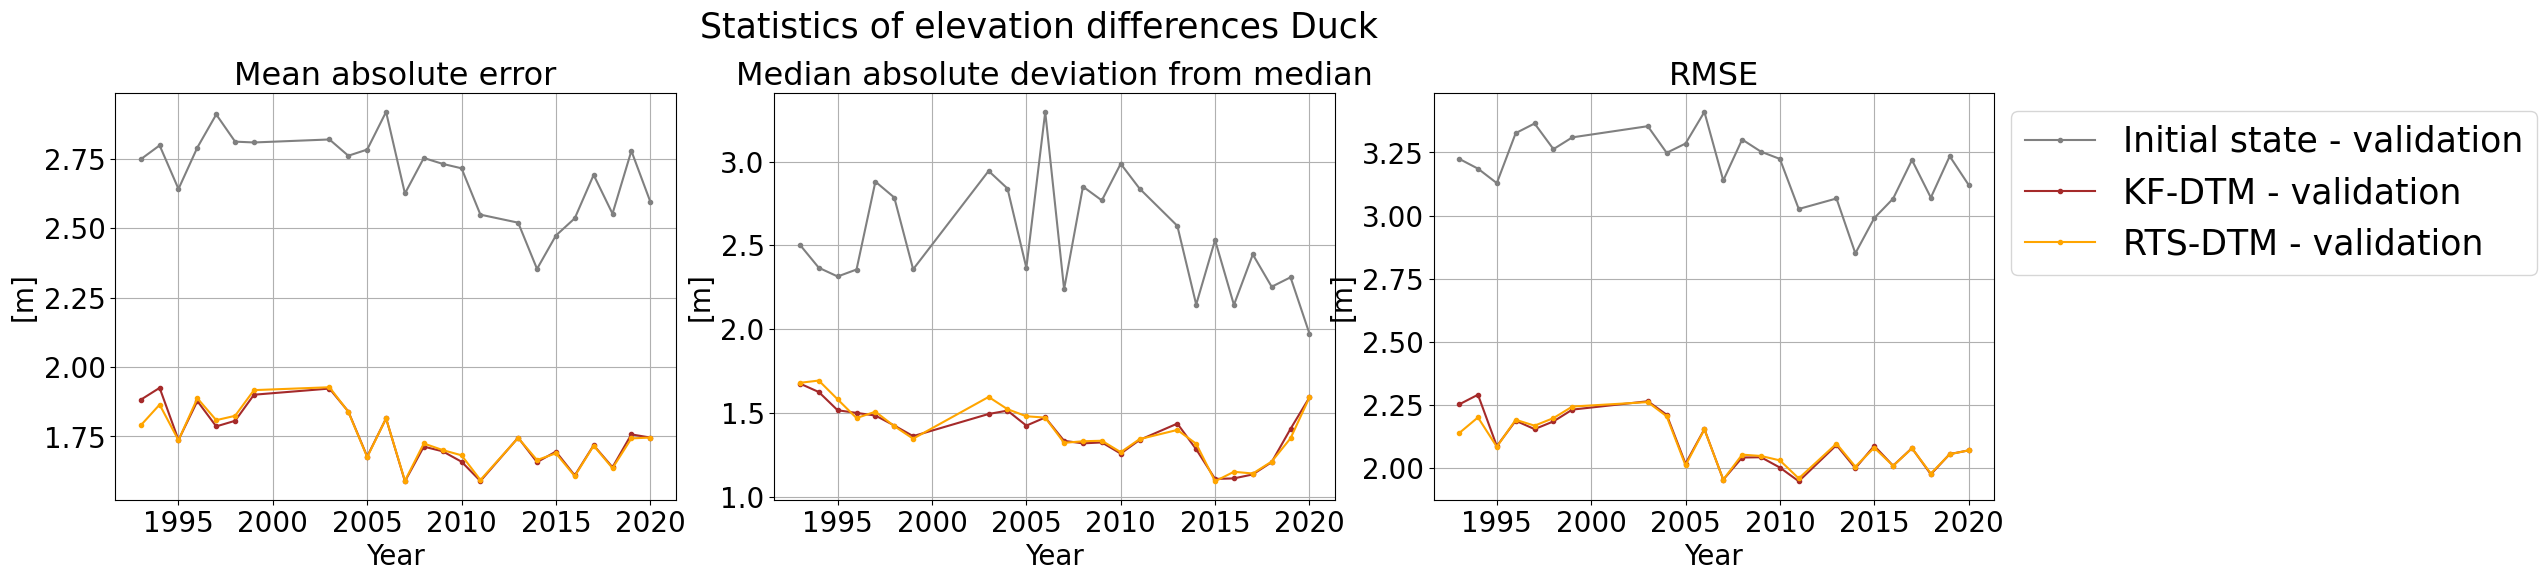

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle(f'Statistics of elevation differences averaged over the entire target area ({len(rts_interp)} points)', y=1.1, fontsize=25)
fig.suptitle(f'Statistics of elevation differences Duck', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error')
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True)

plt.savefig(f'{path_output}Narra_vali_stats_elev-diffs_entire_target_area.png', dpi=300, bbox_inches='tight')

### Maps

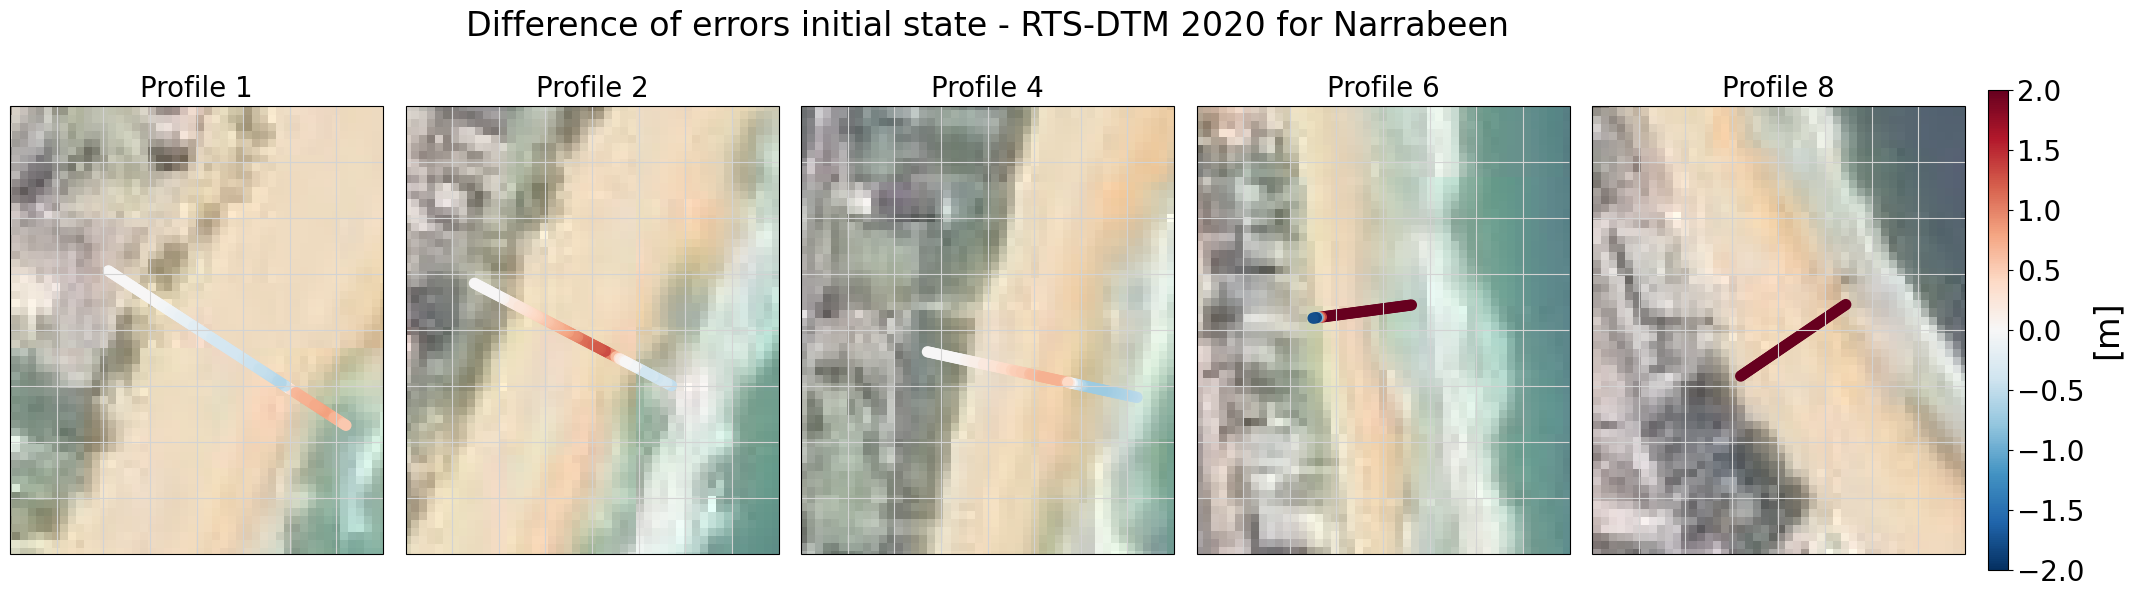

In [50]:
year = '2020'
diff_init = init_interp['init'] - vali_gdf[year]
diff_rts = rts_interp[year] - vali_gdf[year]
diff_rts_init = np.abs(diff_init) - np.abs(diff_rts)

projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
zoom = 15
fig, axs = plt.subplots(1, 5, figsize=(20,8), subplot_kw=dict(projection=request.crs))
fig.tight_layout()

x = vali_gdf.geometry.x
y = vali_gdf.geometry.y
for ax in axs:
    plot = ax.scatter(x, y, marker='o', s=50, c=diff_rts_init, transform=ccrs.PlateCarree(),
                  cmap='RdBu_r', vmin=-2, vmax=2)

axs[0].set_extent([151.304, 151.306, -33.707, -33.705], crs=ccrs.PlateCarree())
axs[0].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[0].add_image(request, zoom, alpha=0.7, zorder=0)
axs[0].set_title('Profile 1')

axs[1].set_extent([151.3025, 151.3045, -33.7105, -33.7085], crs=ccrs.PlateCarree())
axs[1].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[1].add_image(request, zoom, alpha=0.7, zorder=0)
axs[1].set_title('Profile 2')

axs[2].set_extent([151.299, 151.301, -33.718, -33.716], crs=ccrs.PlateCarree())
axs[2].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[2].add_image(request, zoom, alpha=0.7, zorder=0)
axs[2].set_title('Profile 4')

axs[3].set_extent([151.299, 151.301, -33.726, -33.724], crs=ccrs.PlateCarree())
axs[3].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[3].add_image(request, zoom, alpha=0.7, zorder=0)
axs[3].set_title('Profile 6')

axs[4].set_extent([151.301, 151.303, -33.733, -33.731], crs=ccrs.PlateCarree())
axs[4].gridlines(draw_labels=False, zorder=0, color='lightgrey')
axs[4].add_image(request, zoom, alpha=0.7, zorder=0)
axs[4].set_title('Profile 8')

cbar_ax = fig.add_axes([1, 0.2, 0.01, 0.6])
fig.colorbar(plot, cax=cbar_ax).set_label(label='[m]',size=24)

fig.suptitle(f'Difference of errors initial state - RTS-DTM {year} for Narrabeen', y=.9, fontsize=24);

plt.savefig(f'{path_output}Narra_map_diff_errors_init-RTS_{year}.png', dpi=300, bbox_inches='tight')

### For individual profiles

In [29]:
vali_gdf.intersects(profile_polys_red['PF1'])

0      False
1      False
2      False
3      False
4      False
       ...  
682     True
683     True
684     True
685     True
686     True
Length: 687, dtype: bool

## Time series of volume changes

### For each profile

In [30]:
volumes = pd.DataFrame(index=[int(_) for _ in vali_gdf.drop(columns='geometry').columns])
for area in profile_polys_red.keys():
    volumes[f'rts_{area}'] = CD_geometry.compute_volume_changes(rts_interp, profile_polys[area], col_name='', epsg_out=epsg_local)
    volumes[f'kf_{area}'] = CD_geometry.compute_volume_changes(kf_interp, profile_polys[area], col_name='', epsg_out=epsg_local)
    volumes[f'vali_{area}'] = CD_geometry.compute_volume_changes(vali_gdf, profile_polys[area], col_name='', epsg_out=epsg_local)

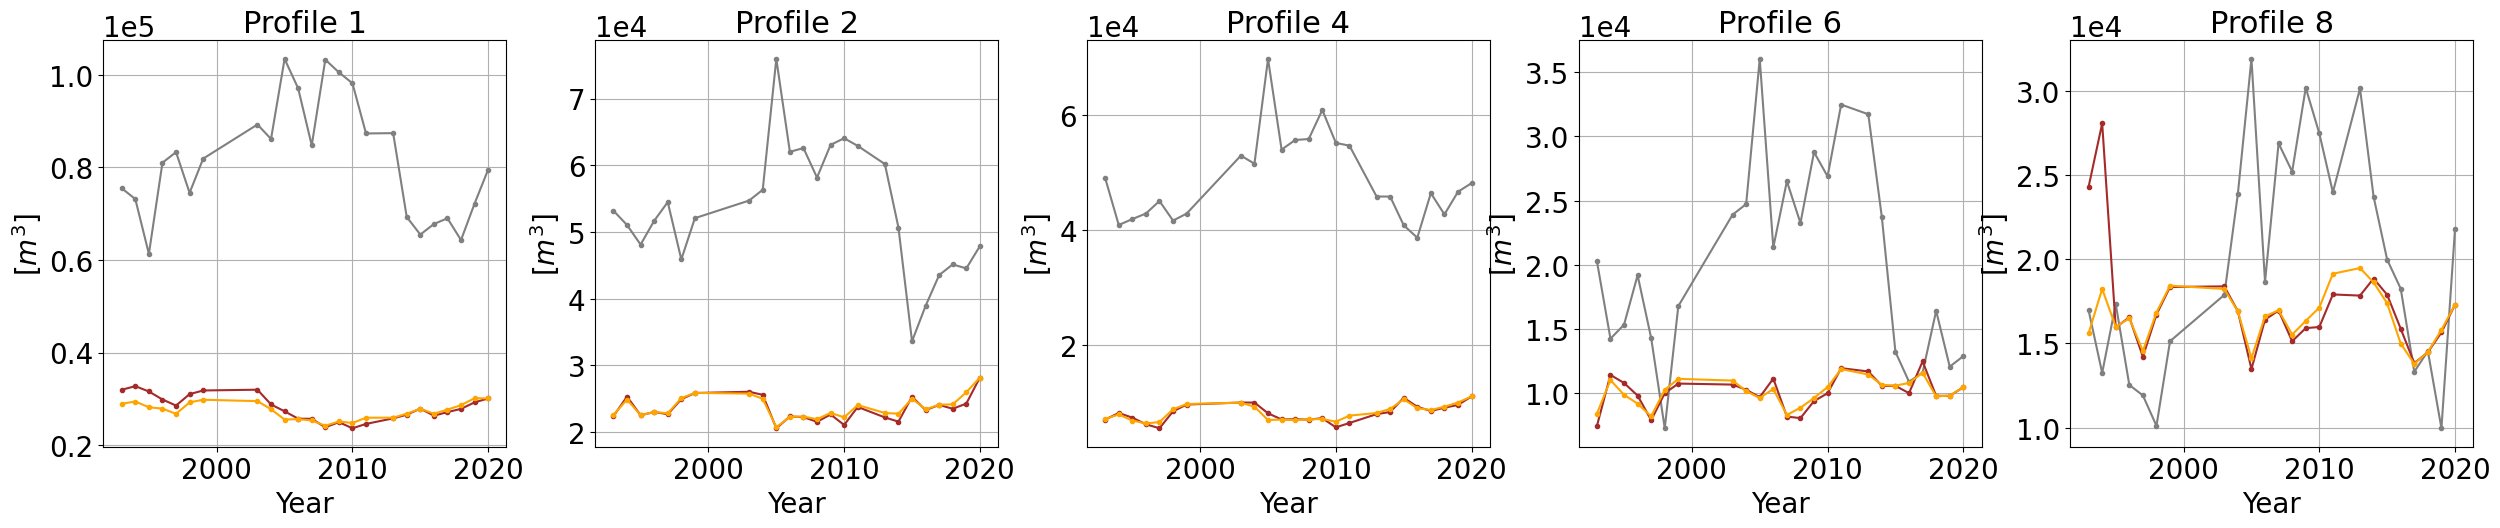

In [31]:
def plot_volume_changes(ax, vol_vali, vol_kf, vol_rts, title_area, legend=False):
    ax.plot(vol_vali.index, vol_vali, '.-', c=c_init, label='Validation')
    ax.plot(vol_kf.index, vol_kf, '.-', c=c_kf, label='KF-DTM')
    ax.plot(vol_rts.index, vol_rts, '.-', c=c_rts, label='RTS-DTM')
    ax.set_ylabel(r'[$m^3$]')
    ax.set_xlabel('Year')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_title(f'{title_area}', fontsize=22)
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=22)
                  
fig, axs = plt.subplots(1,5, figsize=(25,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.22)
# fig.suptitle('Volume changes Terschelling', fontsize=25, y=1.1)

plot_volume_changes(axs[0], volumes['vali_PF1'], volumes['kf_PF1'], volumes['rts_PF1'], 'Profile 1')
plot_volume_changes(axs[1], volumes['vali_PF2'], volumes['kf_PF2'], volumes['rts_PF2'], 'Profile 2')
plot_volume_changes(axs[2], volumes['vali_PF4'], volumes['kf_PF4'], volumes['rts_PF4'], 'Profile 4')
plot_volume_changes(axs[3], volumes['vali_PF6'], volumes['kf_PF6'], volumes['rts_PF6'], 'Profile 6')
plot_volume_changes(axs[4], volumes['vali_PF8'], volumes['kf_PF8'], volumes['rts_PF8'], 'Profile 8', legend=False)

plt.savefig(f'{path_output}Narrabeen_validation_volume_changes_allProfiles.png', dpi=300, bbox_inches='tight')

### Over the entire target_red area

In [32]:
volumes_av = pd.DataFrame(index=[int(_) for _ in vali_gdf.drop(columns='geometry').columns])

volumes_av['vali'] = CD_geometry.compute_volume_changes(vali_gdf, poly_target_red, col_name='', epsg_out=epsg_local)
volumes_av['kf'] = CD_geometry.compute_volume_changes(kf_interp, poly_target_red, col_name='', epsg_out=epsg_local)
volumes_av['rts'] = CD_geometry.compute_volume_changes(rts_interp, poly_target_red, col_name='', epsg_out=epsg_local)

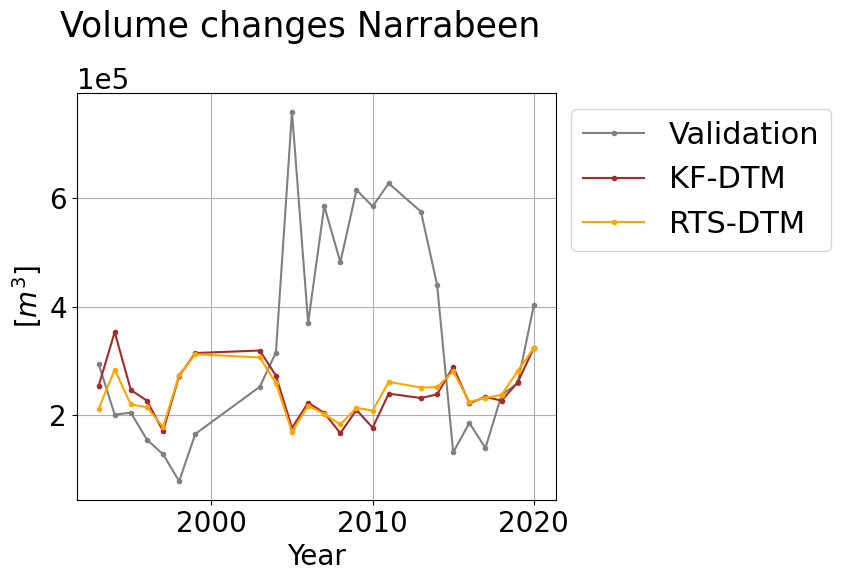

In [33]:
fig, ax = plt.subplots(figsize=(6,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.25)

ax.plot(volumes.index, volumes_av['vali'], '.-', c=c_init, label='Validation')
ax.plot(volumes.index, volumes_av['kf'], '.-', c=c_kf, label='KF-DTM')
ax.plot(volumes.index, volumes_av['rts'], '.-', c=c_rts, label='RTS-DTM')
ax.set_ylabel(r'[$m^3$]')
ax.set_xlabel('Year')
ax.legend(bbox_to_anchor=(1,1), fontsize=22)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.grid()
fig.suptitle('Volume changes Narrabeen', fontsize=25, y=1.1)
plt.savefig(f'{path_output}Narrabeen_validation_volume_changes_average.png', dpi=300, bbox_inches='tight')

### Comparison statistics per profile

In [34]:
rmse = {}
corr = {}
pvalue = {}

for area in profile_polys_red.keys():
    rmse[area] = CD_statistics.RMSE_timeseries(volumes[f'rts_{area}'], volumes[f'vali_{area}'])
    corr[area], pvalue[area] = stats.pearsonr(volumes[f'rts_{area}'], volumes[f'vali_{area}'])

In [35]:
rmse_perc = {}
for area in profile_polys_red.keys():
    rmse_perc[area] = (np.abs(rmse[area])/np.abs(volumes[f'vali_{area}'].mean())) * 100
    print(area, 'rmse in %:', round(rmse_perc[area],1))

PF1 rmse in %: 16.7
PF2 rmse in %: 19.1
PF4 rmse in %: 16.3
PF6 rmse in %: 37.8
PF8 rmse in %: 32.0


In [36]:
for area in profile_polys_red.keys():
    print(f'{area} Correlation: {round(corr[area],2)}, p-value: {round(pvalue[area], 2)}')

PF1 Correlation: -0.63, p-value: 0.0
PF2 Correlation: -0.55, p-value: 0.01
PF4 Correlation: -0.38, p-value: 0.07
PF6 Correlation: -0.0, p-value: 0.99
PF8 Correlation: 0.23, p-value: 0.28


In [37]:
trends = {}
for col in volumes.columns:
    trends[col], _, _ = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int), volumes[col].values)
    
for key, value in trends.items():
    print(key, round(value,1), 'm^3/year')
    

rts_PF1 -28.4 m^3/year
kf_PF1 -178.1 m^3/year
vali_PF1 -142.8 m^3/year
rts_PF2 47.3 m^3/year
kf_PF2 19.4 m^3/year
vali_PF2 -250.2 m^3/year
rts_PF4 84.0 m^3/year
kf_PF4 76.0 m^3/year
vali_PF4 47.1 m^3/year
rts_PF6 42.2 m^3/year
kf_PF6 41.5 m^3/year
vali_PF6 6.0 m^3/year
rts_PF8 -9.3 m^3/year
kf_PF8 -156.7 m^3/year
vali_PF8 198.9 m^3/year


In [38]:
trends

{'rts_PF1': -28.4233,
 'kf_PF1': -178.0809,
 'vali_PF1': -142.831,
 'rts_PF2': 47.313,
 'kf_PF2': 19.4226,
 'vali_PF2': -250.1677,
 'rts_PF4': 84.0346,
 'kf_PF4': 76.0402,
 'vali_PF4': 47.1405,
 'rts_PF6': 42.2461,
 'kf_PF6': 41.4619,
 'vali_PF6': 6.0354,
 'rts_PF8': -9.3112,
 'kf_PF8': -156.6981,
 'vali_PF8': 198.8923}

In [56]:
trend_diff_perc = {}
for area in profile_polys_red.keys():
    trend_diff = trends[f'rts_{area}'] - trends[f'vali_{area}']
    # both trends are neg/pos: perc as quotient of absolute trend diff
    if np.sign(trends[f'rts_{area}']) == np.sign(trends[f'vali_{area}']):
        trend_diff_perc[area] = np.abs(trend_diff) / np.abs(trends[f'vali_{area}']) * 100
    # trends have different signs: perc should be negative
    else:
        trend_diff_perc[area] = trend_diff / trends[f'vali_{area}'] * 100
    
    print(area, 'trend diff in %:', round(trend_diff_perc[area],1))

PF1 trend diff in %: 80.1
PF2 trend diff in %: -118.9
PF4 trend diff in %: 78.3
PF6 trend diff in %: 600.0
PF8 trend diff in %: -104.7


## Animation

#### KF

In [40]:
if animation:
    extent = [-75.78, -75.73, 36.16, 36.2]
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x_state_in_sl_poly = x_state[x_state.intersects(poly_sl_corr)]
    
    x = x_state_in_sl_poly.geometry.x
    y = x_state_in_sl_poly.geometry.y
    anim = CD_visualisation.movie(x_state_in_sl_poly, x, y,
            col_list_kf, first_col='init', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='KF.gif')

#### RTS

In [41]:
if animation:
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    x_state_s_in_sl_poly = x_state_s[x_state_s.intersects(poly_sl_corr)]
    x = x_state_s_in_sl_poly.geometry.x
    y = x_state_s_in_sl_poly.geometry.y
    
    anim_RTS = CD_visualisation.movie(x_state_s_in_sl_poly, x, y,
                col_list_s, first_col='x_s_2020', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='RTS.gif')